<a href="https://colab.research.google.com/github/tokiror/maple-scholars-2026/blob/main/Final_TWSA_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                 date          NW          NE          SW          SE  \
0 2002-04-17 12:00:00  106.691017  118.791039  114.785095  139.540741   
1 2002-05-10 12:00:00  110.634872  119.623810  115.281700  128.358765   
2 2002-08-16 12:00:00   25.081923   22.657181   19.328081   15.697092   
3 2002-09-16 00:00:00   18.622929   15.482160   12.130322   11.437850   
4 2002-10-16 12:00:00   12.749219   13.249780    6.099244    7.809370   

   Kongwa_mean  
0   119.951973  
1   118.474785  
2    20.691069  
3    14.418315  
4     9.976904  


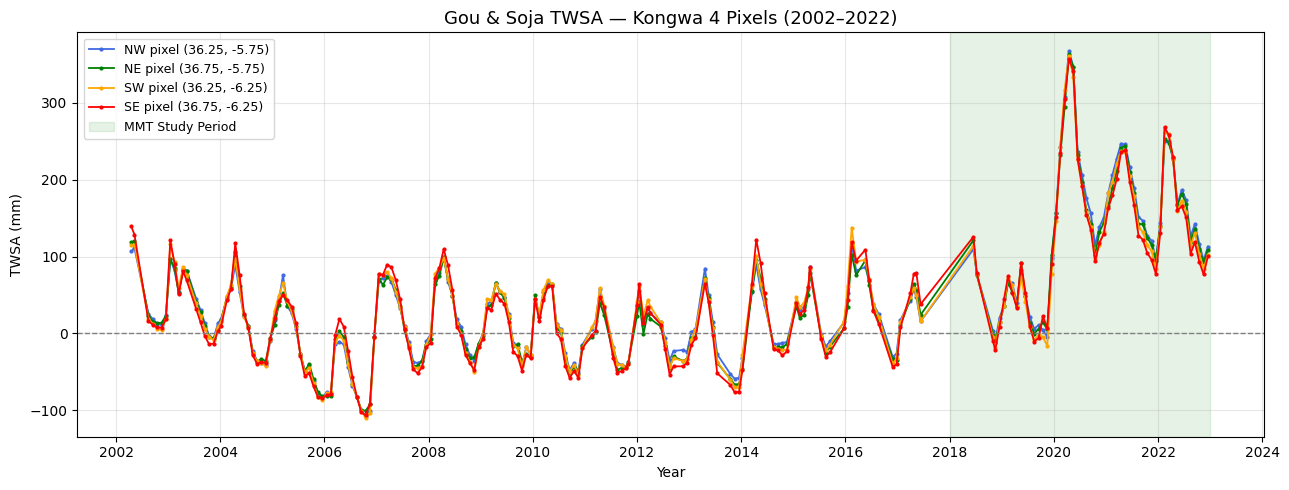

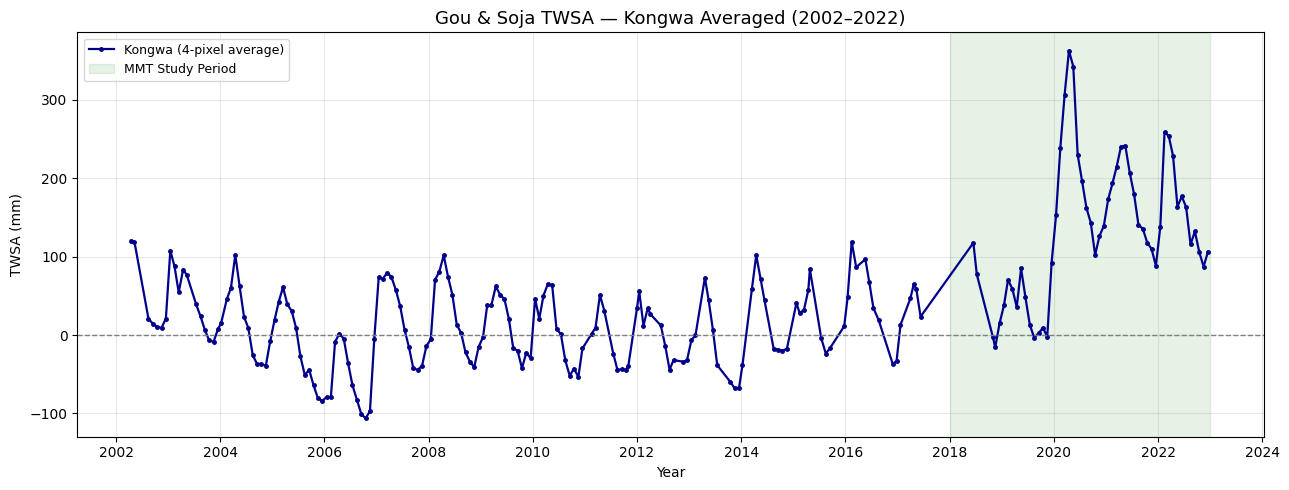

Kongwa (~0.25 deg): half-width 0.25 deg
Ring 1 (~0.5 deg): half-width 0.5 deg
Ring 2 (~1.0 deg): half-width 1.0 deg
Ring 3 (~2.0 deg): half-width 2.0 deg
                 date  Kongwa (~0.25 deg)  Ring 1 (~0.5 deg)  \
0 2002-04-17 12:00:00          119.951973         119.951973   
1 2002-05-10 12:00:00          118.474785         118.474785   
2 2002-08-16 12:00:00           20.691069          20.691069   
3 2002-09-16 00:00:00           14.418315          14.418315   
4 2002-10-16 12:00:00            9.976904           9.976904   

   Ring 2 (~1.0 deg)  Ring 3 (~2.0 deg)  
0         135.950256         156.303436  
1         129.494949         144.135941  
2          23.838348          24.321390  
3          16.959251          14.515314  
4          11.370490           6.009069  


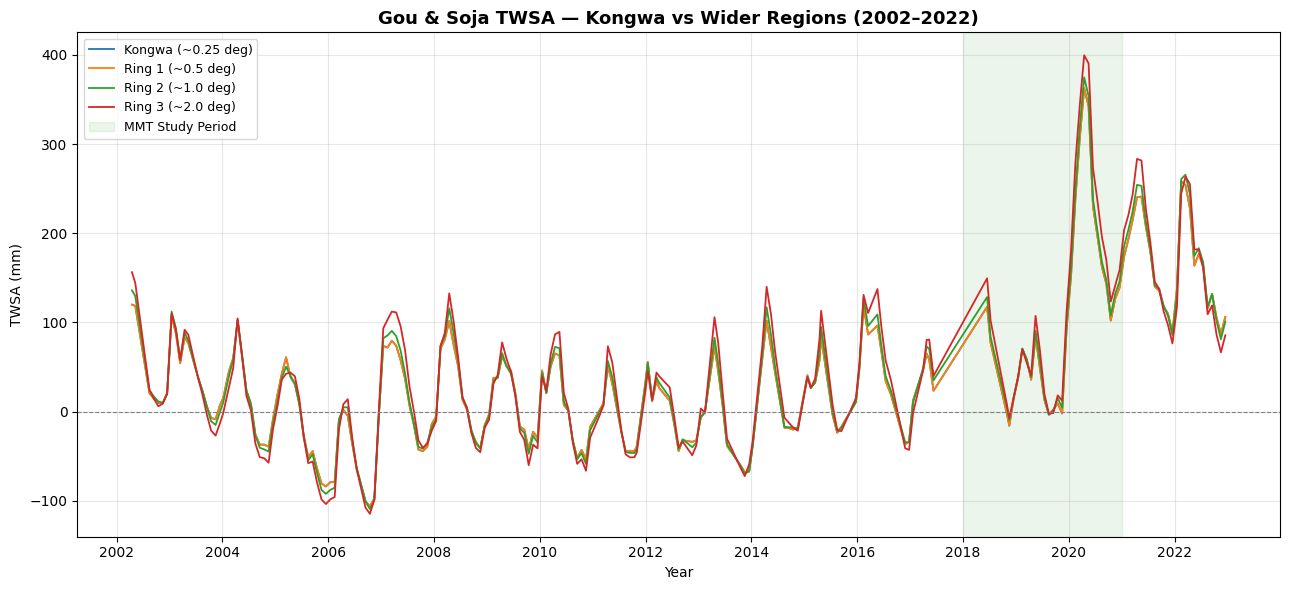


Correlation of each ring with Kongwa (TWSA):
  Ring 1 (~0.5 deg): r = 1.000
  Ring 2 (~1.0 deg): r = 0.999
  Ring 3 (~2.0 deg): r = 0.990

Saved: Kongwa_TWSA_rings.csv and Kongwa_TWSA_4pixel.csv


In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
#  1. LOAD DATA
# ============================================================
ds = xr.open_dataset('GRACE-SeDA_v1_2002_2022.nc')
mjd_epoch = pd.Timestamp('1858-11-17')
dates = mjd_epoch + pd.to_timedelta(ds.time.values, unit='D')

def clean(series):
    """Mask out physically impossible artifact values."""
    return series.where((series > -1000) & (series < 1000))

# ============================================================
#  2. THE FOUR KONGWA PIXELS (with corrected labels)
# ============================================================
# Kongwa 2x2 grid: NW, NE, SW, SE
p_nw = clean(ds['twsa'].sel(longitude=36.25, latitude=-5.75))
p_ne = clean(ds['twsa'].sel(longitude=36.75, latitude=-5.75))
p_sw = clean(ds['twsa'].sel(longitude=36.25, latitude=-6.25))
p_se = clean(ds['twsa'].sel(longitude=36.75, latitude=-6.25))

df = pd.DataFrame({
    'date': dates,
    'NW': p_nw, 'NE': p_ne, 'SW': p_sw, 'SE': p_se,
})
# The joint Kongwa series = average of the 4 pixels
df['Kongwa_mean'] = df[['NW', 'NE', 'SW', 'SE']].mean(axis=1)
print(df.head())

def style(ax, title):
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.10, color='green', label='MMT Study Period')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ============================================================
#  3. FOUR-PIXEL PLOT (fixed legend)
# ============================================================
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['date'], df['NW'], color='royalblue', lw=1.3, marker='o', ms=2, label='NW pixel (36.25, -5.75)')
ax.plot(df['date'], df['NE'], color='green',     lw=1.3, marker='o', ms=2, label='NE pixel (36.75, -5.75)')
ax.plot(df['date'], df['SW'], color='orange',    lw=1.3, marker='o', ms=2, label='SW pixel (36.25, -6.25)')
ax.plot(df['date'], df['SE'], color='red',       lw=1.3, marker='o', ms=2, label='SE pixel (36.75, -6.25)')
style(ax, 'Gou & Soja TWSA — Kongwa 4 Pixels (2002–2022)')
plt.tight_layout(); plt.savefig('Kongwa_4pixels.png', dpi=150); plt.show()

# ============================================================
#  4. JOINT KONGWA SERIES (the 4 averaged into 1)
# ============================================================
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['date'], df['Kongwa_mean'], color='darkblue', lw=1.6, marker='o', ms=2.5,
        label='Kongwa (4-pixel average)')
style(ax, 'Gou & Soja TWSA — Kongwa Averaged (2002–2022)')
plt.tight_layout(); plt.savefig('Kongwa_averaged.png', dpi=150); plt.show()

# ============================================================
#  5. CONCENTRIC RINGS AROUND KONGWA
#     (same half-widths as the SPEI ring analysis)
# ============================================================
# Kongwa centre (middle of the 2x2 grid)
lon0, lat0 = 36.50, -6.00

rings = {
    'Kongwa (~0.25 deg)': 0.25,
    'Ring 1 (~0.5 deg)':  0.5,
    'Ring 2 (~1.0 deg)':  1.0,
    'Ring 3 (~2.0 deg)':  2.0,
}

def ring_mean(hw):
    """Average all grid cells within a box of half-width hw around Kongwa centre."""
    lat_lo, lat_hi = sorted([lat0 - hw, lat0 + hw])
    lon_lo, lon_hi = sorted([lon0 - hw, lon0 + hw])
    box = ds['twsa'].sel(latitude=slice(lat_hi, lat_lo),   # note: lat often descends
                         longitude=slice(lon_lo, lon_hi))
    # if the descending-latitude slice came back empty, try ascending
    if box.latitude.size == 0:
        box = ds['twsa'].sel(latitude=slice(lat_lo, lat_hi),
                             longitude=slice(lon_lo, lon_hi))
    box = clean(box)
    # average over both spatial dimensions, leaving a time series
    return box.mean(dim=['latitude', 'longitude'], skipna=True).values

ring_df = pd.DataFrame({'date': dates})
for name, hw in rings.items():
    ring_df[name] = ring_mean(hw)
    n_cells = ds['twsa'].sel(
        latitude=slice(*sorted([lat0+hw, lat0-hw])[::-1]),
        longitude=slice(lon0-hw, lon0+hw)).latitude.size
    print(f"{name}: half-width {hw} deg")
print(ring_df.head())

# ============================================================
#  6. PLOT THE RINGS OVERLAID
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))
for name in rings:
    ax.plot(ring_df['date'], ring_df[name], lw=1.3, label=name)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2020-12-31'),
           alpha=0.08, color='green', label='MMT Study Period')
ax.set_title('Gou & Soja TWSA — Kongwa vs Wider Regions (2002–2022)', fontsize=13, weight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.savefig('Kongwa_TWSA_rings.png', dpi=150); plt.show()

# ============================================================
#  7. HOW CLOSELY DOES EACH RING TRACK KONGWA?
# ============================================================
base = 'Kongwa (~0.25 deg)'
print("\nCorrelation of each ring with Kongwa (TWSA):")
for name in rings:
    if name == base:
        continue
    r = np.corrcoef(ring_df[base].fillna(0), ring_df[name].fillna(0))[0, 1]
    print(f"  {name}: r = {r:.3f}")

# Save the averaged series for later use (e.g. the lag analysis)
ring_df.to_csv('Kongwa_TWSA_rings.csv', index=False)
df[['date','NW','NE','SW','SE','Kongwa_mean']].to_csv('Kongwa_TWSA_4pixel.csv', index=False)
print("\nSaved: Kongwa_TWSA_rings.csv and Kongwa_TWSA_4pixel.csv")

                 date          NW          NE          SW          SE  \
0 2002-04-17 12:00:00  106.691017  118.791039  114.785095  139.540741   
1 2002-05-10 12:00:00  110.634872  119.623810  115.281700  128.358765   
2 2002-08-16 12:00:00   25.081923   22.657181   19.328081   15.697092   
3 2002-09-16 00:00:00   18.622929   15.482160   12.130322   11.437850   
4 2002-10-16 12:00:00   12.749219   13.249780    6.099244    7.809370   

   Kongwa_mean  
0   119.951973  
1   118.474785  
2    20.691069  
3    14.418315  
4     9.976904  


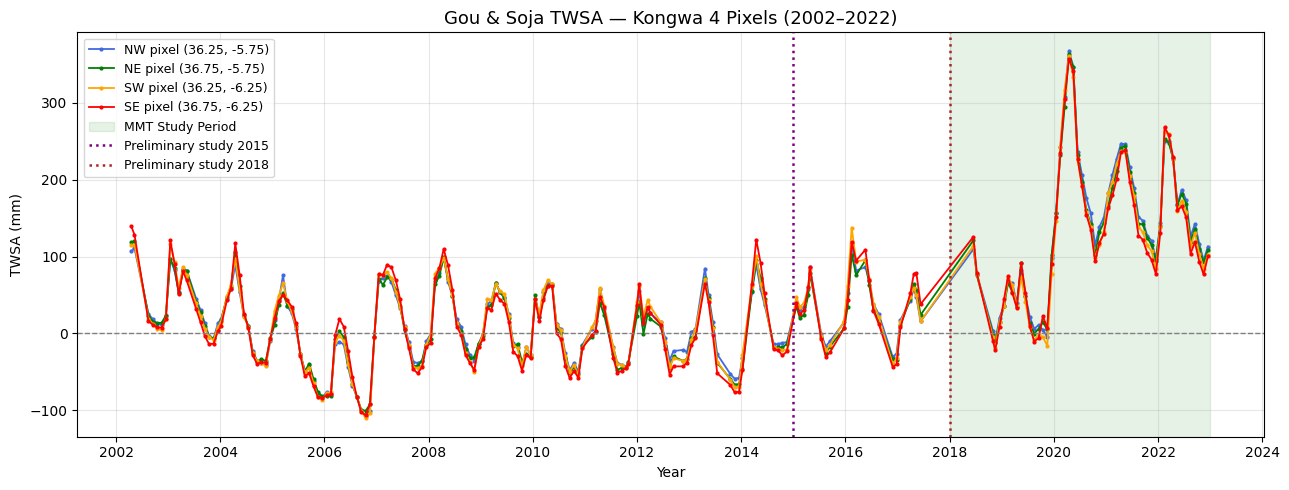

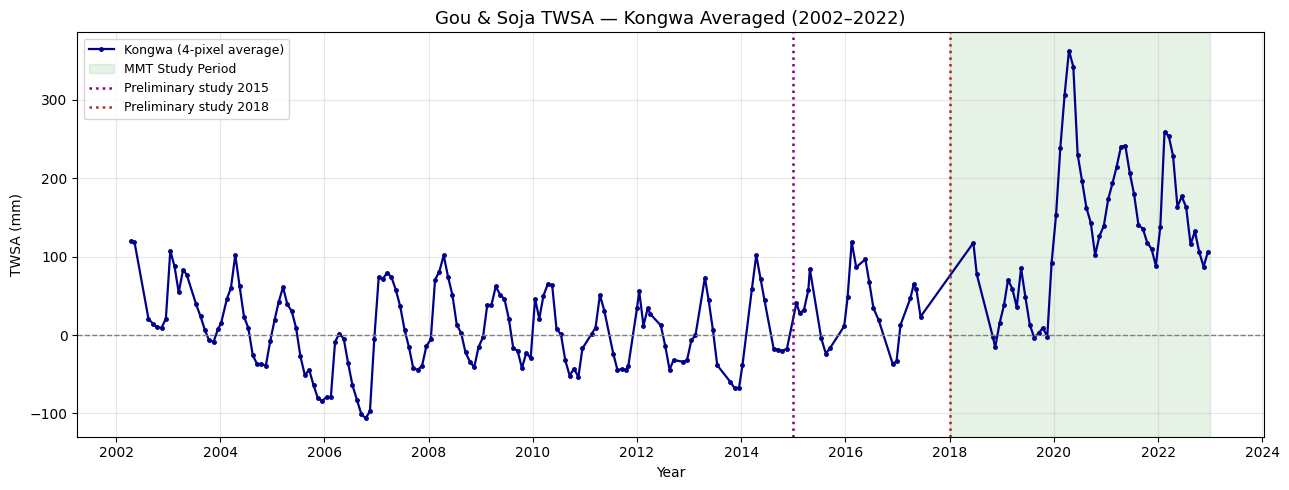

Kongwa (~0.25 deg): half-width 0.25 deg
Ring 1 (~0.5 deg): half-width 0.5 deg
Ring 2 (~1.0 deg): half-width 1.0 deg
Ring 3 (~2.0 deg): half-width 2.0 deg
                 date  Kongwa (~0.25 deg)  Ring 1 (~0.5 deg)  \
0 2002-04-17 12:00:00          119.951973         119.951973   
1 2002-05-10 12:00:00          118.474785         118.474785   
2 2002-08-16 12:00:00           20.691069          20.691069   
3 2002-09-16 00:00:00           14.418315          14.418315   
4 2002-10-16 12:00:00            9.976904           9.976904   

   Ring 2 (~1.0 deg)  Ring 3 (~2.0 deg)  
0         135.950256         156.303436  
1         129.494949         144.135941  
2          23.838348          24.321390  
3          16.959251          14.515314  
4          11.370490           6.009069  


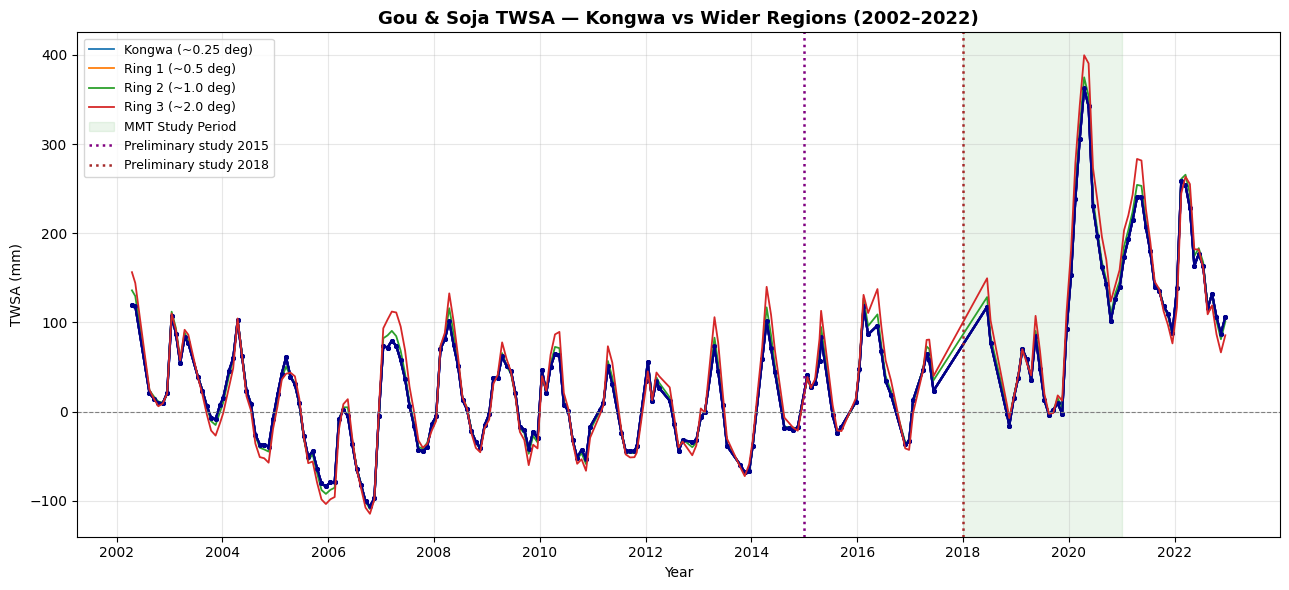


Correlation of each ring with Kongwa (TWSA):
  Ring 1 (~0.5 deg): r = 1.000
  Ring 2 (~1.0 deg): r = 0.999
  Ring 3 (~2.0 deg): r = 0.990

Saved: Kongwa_TWSA_rings.csv and Kongwa_TWSA_4pixel.csv


In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
#  1. LOAD DATA
# ============================================================
ds = xr.open_dataset('GRACE-SeDA_v1_2002_2022.nc', engine='h5netcdf')
mjd_epoch = pd.Timestamp('1858-11-17')
dates = mjd_epoch + pd.to_timedelta(ds.time.values, unit='D')

def clean(series):
    """Mask out physically impossible artifact values."""
    return series.where((series > -1000) & (series < 1000))

# ============================================================
#  2. THE FOUR KONGWA PIXELS (with corrected labels)
# ============================================================
# Kongwa 2x2 grid: NW, NE, SW, SE
p_nw = clean(ds['twsa'].sel(longitude=36.25, latitude=-5.75))
p_ne = clean(ds['twsa'].sel(longitude=36.75, latitude=-5.75))
p_sw = clean(ds['twsa'].sel(longitude=36.25, latitude=-6.25))
p_se = clean(ds['twsa'].sel(longitude=36.75, latitude=-6.25))

df = pd.DataFrame({
    'date': dates,
    'NW': p_nw, 'NE': p_ne, 'SW': p_sw, 'SE': p_se,
})
# The joint Kongwa series = average of the 4 pixels
df['Kongwa_mean'] = df[['NW', 'NE', 'SW', 'SE']].mean(axis=1)
print(df.head())

def style(ax, title):
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.10, color='green', label='MMT Study Period')
    # Vertical dotted lines marking the preliminary mycotoxin studies
    ax.axvline(pd.Timestamp('2015-01-01'), color='purple', ls=':', lw=1.8,
               label='Preliminary study 2015')
    ax.axvline(pd.Timestamp('2018-01-01'), color='brown', ls=':', lw=1.8,
               label='Preliminary study 2018')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


#  3. FOUR-PIXEL PLOT (fixed legend)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['date'], df['NW'], color='royalblue', lw=1.3, marker='o', ms=2, label='NW pixel (36.25, -5.75)')
ax.plot(df['date'], df['NE'], color='green',     lw=1.3, marker='o', ms=2, label='NE pixel (36.75, -5.75)')
ax.plot(df['date'], df['SW'], color='orange',    lw=1.3, marker='o', ms=2, label='SW pixel (36.25, -6.25)')
ax.plot(df['date'], df['SE'], color='red',       lw=1.3, marker='o', ms=2, label='SE pixel (36.75, -6.25)')
style(ax, 'Gou & Soja TWSA — Kongwa 4 Pixels (2002–2022)')
plt.tight_layout(); plt.savefig('Kongwa_4pixels.png', dpi=150); plt.show()


#  4. JOINT KONGWA SERIES (the 4 averaged into 1)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['date'], df['Kongwa_mean'], color='darkblue', lw=1.6, marker='o', ms=2.5,
        label='Kongwa (4-pixel average)')
style(ax, 'Gou & Soja TWSA — Kongwa Averaged (2002–2022)')
plt.tight_layout(); plt.savefig('Kongwa_averaged.png', dpi=150); plt.show()

#  5. CONCENTRIC RINGS AROUND KONGWA
#     (same half-widths as the SPEI ring analysis)
# Kongwa centre (middle of the 2x2 grid)
lon0, lat0 = 36.50, -6.00

rings = {
    'Kongwa (~0.25 deg)': 0.25,
    'Ring 1 (~0.5 deg)':  0.5,
    'Ring 2 (~1.0 deg)':  1.0,
    'Ring 3 (~2.0 deg)':  2.0,
}

def ring_mean(hw):
    """Average all grid cells within a box of half-width hw around Kongwa centre."""
    lat_lo, lat_hi = sorted([lat0 - hw, lat0 + hw])
    lon_lo, lon_hi = sorted([lon0 - hw, lon0 + hw])
    box = ds['twsa'].sel(latitude=slice(lat_hi, lat_lo),   # note: lat often descends
                         longitude=slice(lon_lo, lon_hi))
    # if the descending-latitude slice came back empty, try ascending
    if box.latitude.size == 0:
        box = ds['twsa'].sel(latitude=slice(lat_lo, lat_hi),
                             longitude=slice(lon_lo, lon_hi))
    box = clean(box)
    # average over both spatial dimensions, leaving a time series
    return box.mean(dim=['latitude', 'longitude'], skipna=True).values

ring_df = pd.DataFrame({'date': dates})
for name, hw in rings.items():
    ring_df[name] = ring_mean(hw)
    print(f"{name}: half-width {hw} deg")
print(ring_df.head())

#  6. PLOT THE RINGS OVERLAID
fig, ax = plt.subplots(figsize=(13, 6))
for name in rings:
    ax.plot(df['date'], df['Kongwa_mean'], color='darkblue', lw=1.6, marker='o', ms=2.5,)
    ax.plot(ring_df['date'], ring_df[name], lw=1.3, label=name)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2020-12-31'),
           alpha=0.08, color='green', label='MMT Study Period')
# Vertical dotted lines marking the preliminary mycotoxin studies
ax.axvline(pd.Timestamp('2015-01-01'), color='purple', ls=':', lw=1.8, label='Preliminary study 2015')
ax.axvline(pd.Timestamp('2018-01-01'), color='brown', ls=':', lw=1.8, label='Preliminary study 2018')
ax.set_title('Gou & Soja TWSA — Kongwa vs Wider Regions (2002–2022)', fontsize=13, weight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('TWSA (mm)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.savefig('Kongwa_TWSA_rings.png', dpi=150); plt.show()

#  7. HOW CLOSELY DOES EACH RING TRACK KONGWA?
#
base = 'Kongwa (~0.25 deg)'
print("\nCorrelation of each ring with Kongwa (TWSA):")
for name in rings:
    if name == base:
        continue
    a = ring_df[base]
    b = ring_df[name]
    mask = a.notna() & b.notna()          # correlate only where both exist
    r = np.corrcoef(a[mask], b[mask])[0, 1]
    print(f"  {name}: r = {r:.3f}")

#  8. SAVE OUTPUTS (feeds the later lag analysis)
ring_df.to_csv('Kongwa_TWSA_rings.csv', index=False)
df[['date','NW','NE','SW','SE','Kongwa_mean']].to_csv('Kongwa_TWSA_4pixel.csv', index=False)
print("\nSaved: Kongwa_TWSA_rings.csv and Kongwa_TWSA_4pixel.csv")